In [1]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
filename = list(uploaded.keys())[0]  # automatically grabs whatever filename Colab saved it as
df = pd.read_csv(filename)
df.head()

Saving cleaned_full_dataset (1).csv to cleaned_full_dataset (1).csv


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,MonthlyCharges,Churn,InternetService_DSL,InternetService_Fiber optic,Contract_Month-to-month,Contract_One year,Contract_Two year
0,0,0,0,-1.277445,0,0,-1.321350,1,1,0,1,0,0
1,1,0,0,0.351370,1,0,-1.321350,0,1,0,0,1,0
2,0,0,1,0.799294,1,0,-1.520755,0,1,0,1,0,0
3,0,0,0,-1.277445,1,0,0.373593,1,1,0,0,1,0
4,1,0,0,1.410099,1,0,-0.457261,0,0,1,1,0,0


In [2]:
X = df.drop(columns=['Churn'])
churn_labels = df['Churn']  # keep this for later, don't use it in clustering

X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6741 entries, 0 to 6740
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       6741 non-null   int64  
 1   SeniorCitizen                6741 non-null   int64  
 2   Dependents                   6741 non-null   int64  
 3   tenure                       6741 non-null   float64
 4   PhoneService                 6741 non-null   int64  
 5   MultipleLines                6741 non-null   int64  
 6   MonthlyCharges               6741 non-null   float64
 7   InternetService_DSL          6741 non-null   int64  
 8   InternetService_Fiber optic  6741 non-null   int64  
 9   Contract_Month-to-month      6741 non-null   int64  
 10  Contract_One year            6741 non-null   int64  
 11  Contract_Two year            6741 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 632.1 KB


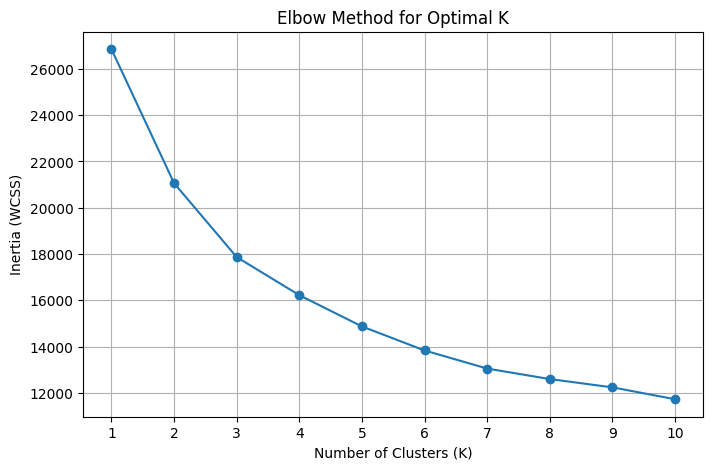

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal K')
plt.xticks(K_range)
plt.grid(True)
plt.show()

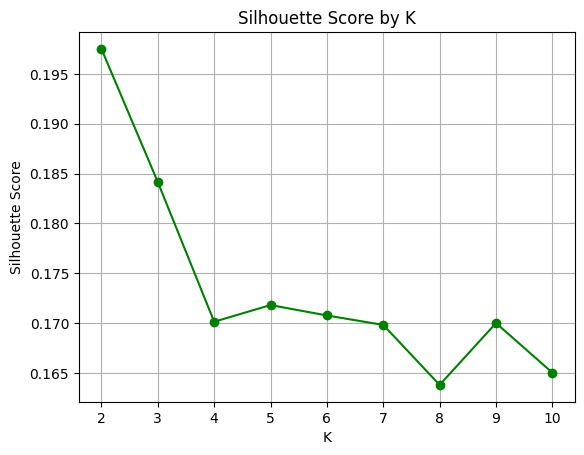

In [4]:
from sklearn.metrics import silhouette_score

sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

plt.plot(range(2, 11), sil_scores, marker='o', color='green')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by K')
plt.grid(True)
plt.show()

In [5]:
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,1589
1,1124
2,1882
3,2146


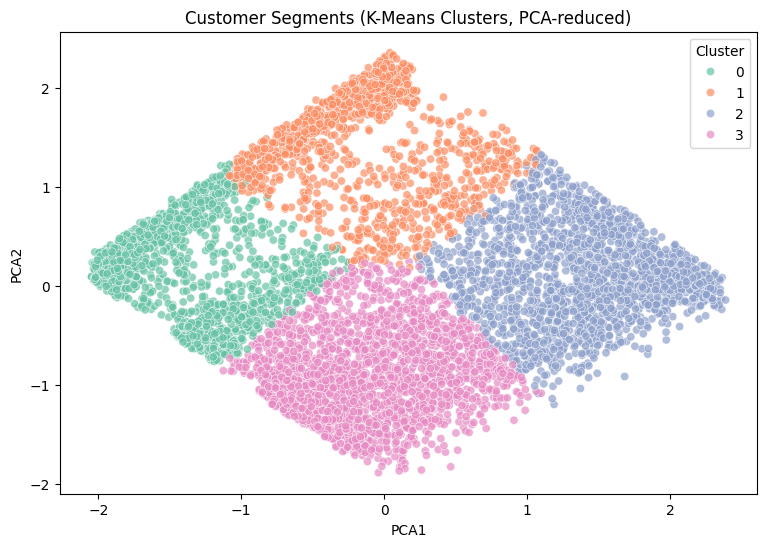

Explained variance ratio: [0.303226   0.19515615]
Total variance explained: 0.49838214768613376


In [6]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
components = pca.fit_transform(X)
df['PCA1'] = components[:, 0]
df['PCA2'] = components[:, 1]

plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='Set2', alpha=0.7)
plt.title('Customer Segments (K-Means Clusters, PCA-reduced)')
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

In [7]:
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 20)

# Average value of each feature per cluster
cluster_profile = df.groupby('Cluster')[X.columns].mean().round(3)
print(cluster_profile)

print("\nChurn rate by cluster:")
print(df.groupby('Cluster')['Churn'].mean().round(3))

         gender  SeniorCitizen  Dependents  tenure  PhoneService  MultipleLines  MonthlyCharges  InternetService_DSL  InternetService_Fiber optic  Contract_Month-to-month  Contract_One year  \
Cluster                                                                                                                                                                                         
0         0.522          0.072       0.332  -0.858         0.777          0.429          -1.028                0.557                        0.443                    0.508              0.242   
1         0.506          0.076       0.448   0.899         0.727          0.401          -0.989                0.560                        0.440                    0.541              0.222   
2         0.502          0.217       0.335   1.071         0.997          0.437           0.947                0.543                        0.457                    0.549              0.208   
3         0.489          0.243     

In [8]:
from google.colab import files

df.to_csv('clustered_customer_data.csv', index=False)
files.download('clustered_customer_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>